# 🤖 DermaAI Vision - Entrenamiento del Agente de Aprendizaje por Refuerzo

Este notebook entrena un agente **DQN (Deep Q-Network)** que decide cuándo escalar un caso dermatológico a un especialista humano.

## Arquitectura del Agente

- **Estado**: Vector de probabilidades del modelo CNN (7 valores) + confianza máxima
- **Acciones**: 0 = No escalar, 1 = Escalar a especialista
- **Recompensas**: Basadas en el riesgo del diagnóstico y la confianza del modelo

---

## 1. Configuración del Entorno

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import json
import os
from collections import deque
import random
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Cargar el Modelo CNN Entrenado

In [2]:
# Cargar el modelo CNN (subir los archivos del notebook anterior)
try:
    from google.colab import files
    print("📤 Por favor, sube los siguientes archivos:")
    print("   - dermaai_model_final.keras")
    print("   - class_info.json")
    uploaded = files.upload()
except:
    print("⚠️ No estás en Colab. Asegúrate de tener los archivos en el directorio actual.")

📤 Por favor, sube los siguientes archivos:
   - dermaai_model_final.keras
   - class_info.json


Saving class_info.json to class_info.json
Saving dermaai_model_final.keras to dermaai_model_final.keras


In [3]:
# Cargar modelo CNN
cnn_model = keras.models.load_model('dermaai_model_final.keras')
print("✅ Modelo CNN cargado")

# Cargar información de clases
with open('class_info.json', 'r') as f:
    class_info = json.load(f)

CLASS_NAMES = class_info['class_names']
NUM_CLASSES = class_info['num_classes']

print(f"📊 Clases: {CLASS_NAMES}")

✅ Modelo CNN cargado
📊 Clases: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


## 3. Definir el Sistema de Riesgo y Recompensas

In [4]:
# Categorización de riesgo por diagnóstico
RISK_LEVELS = {
    'Melanoma, NOS': 'CRITICAL',           # Riesgo crítico - siempre escalar
    'Squamous cell carcinoma, NOS': 'HIGH', # Riesgo alto
    'Basal cell carcinoma': 'HIGH',         # Riesgo alto
    'Solar or actinic keratosis': 'MEDIUM', # Riesgo medio (precanceroso)
    'Pigmented benign keratosis': 'LOW',    # Riesgo bajo
    'Dermatofibroma': 'LOW',                # Riesgo bajo
    'Nevus': 'LOW'                          # Riesgo bajo
}

# Umbrales de confianza
CONFIDENCE_THRESHOLD_HIGH = 0.85
CONFIDENCE_THRESHOLD_LOW = 0.60

def calculate_reward(prediction_probs, predicted_class, action, confidence):
    """
    Calcula la recompensa para el agente RL.

    Args:
        prediction_probs: Probabilidades de cada clase
        predicted_class: Clase predicha (índice)
        action: 0 = No escalar, 1 = Escalar
        confidence: Nivel de confianza de la predicción

    Returns:
        reward: Valor de recompensa
    """
    class_name = CLASS_NAMES[predicted_class]
    risk = RISK_LEVELS.get(class_name, 'MEDIUM')

    # Calcular entropía (incertidumbre)
    entropy = -np.sum(prediction_probs * np.log(prediction_probs + 1e-10))
    normalized_entropy = entropy / np.log(NUM_CLASSES)  # Normalizar 0-1

    reward = 0

    if action == 1:  # ESCALAR
        if risk == 'CRITICAL':
            reward = 15  # Excelente decisión
        elif risk == 'HIGH' and confidence < CONFIDENCE_THRESHOLD_HIGH:
            reward = 10  # Buena decisión
        elif risk == 'HIGH' and confidence >= CONFIDENCE_THRESHOLD_HIGH:
            reward = 5   # Aceptable pero quizás innecesario
        elif risk == 'MEDIUM' and confidence < CONFIDENCE_THRESHOLD_LOW:
            reward = 8   # Prudente ante incertidumbre
        elif normalized_entropy > 0.5:
            reward = 6   # Bueno escalar si hay mucha incertidumbre
        elif risk == 'LOW' and confidence >= CONFIDENCE_THRESHOLD_HIGH:
            reward = -5  # Innecesario, cargando al especialista
        else:
            reward = 2   # Neutral

    else:  # NO ESCALAR
        if risk == 'CRITICAL':
            reward = -20  # Error grave - nunca dejar pasar melanoma
        elif risk == 'HIGH' and confidence < CONFIDENCE_THRESHOLD_LOW:
            reward = -15  # Error peligroso
        elif risk == 'HIGH' and confidence >= CONFIDENCE_THRESHOLD_HIGH:
            reward = -5   # Riesgoso pero modelo está seguro
        elif risk == 'MEDIUM' and confidence < CONFIDENCE_THRESHOLD_LOW:
            reward = -8   # Debería escalar por incertidumbre
        elif risk == 'LOW' and confidence >= CONFIDENCE_THRESHOLD_HIGH:
            reward = 10   # Perfecto - ahorra tiempo del especialista
        elif risk == 'LOW' and confidence >= CONFIDENCE_THRESHOLD_LOW:
            reward = 5    # Buena decisión
        else:
            reward = 0    # Neutral

    return reward

print("✅ Sistema de recompensas definido")
print(f"\n📊 Niveles de riesgo por diagnóstico:")
for class_name, risk in RISK_LEVELS.items():
    emoji = {'CRITICAL': '🔴', 'HIGH': '🟠', 'MEDIUM': '🟡', 'LOW': '🟢'}[risk]
    print(f"   {emoji} {class_name}: {risk}")

✅ Sistema de recompensas definido

📊 Niveles de riesgo por diagnóstico:
   🔴 Melanoma, NOS: CRITICAL
   🟠 Squamous cell carcinoma, NOS: HIGH
   🟠 Basal cell carcinoma: HIGH
   🟡 Solar or actinic keratosis: MEDIUM
   🟢 Pigmented benign keratosis: LOW
   🟢 Dermatofibroma: LOW
   🟢 Nevus: LOW


## 4. Construir el Agente DQN

In [5]:
class EscalationAgent:
    """
    Agente DQN para decidir cuándo escalar un caso a especialista.
    """

    def __init__(self, state_size=9, action_size=2):
        """
        Args:
            state_size: Tamaño del vector de estado (7 probs + max_conf + entropy)
            action_size: Número de acciones (0=No escalar, 1=Escalar)
        """
        self.state_size = state_size
        self.action_size = action_size

        # Hiperparámetros
        self.gamma = 0.95           # Factor de descuento
        self.epsilon = 1.0          # Exploración inicial
        self.epsilon_min = 0.01     # Exploración mínima
        self.epsilon_decay = 0.995  # Decaimiento de exploración
        self.learning_rate = 0.001
        self.batch_size = 32

        # Buffer de experiencia
        self.memory = deque(maxlen=2000)

        # Red neuronal principal y target
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        """Construye la red neuronal del agente."""
        model = keras.Sequential([
            layers.Input(shape=(self.state_size,)),
            layers.Dense(64, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(32, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(16, activation='relu'),
            layers.Dense(self.action_size, activation='linear')
        ])

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=self.learning_rate),
            loss='mse'
        )
        return model

    def update_target_model(self):
        """Actualiza la red target con los pesos de la red principal."""
        self.target_model.set_weights(self.model.get_weights())

    def get_state(self, prediction_probs):
        """
        Construye el vector de estado a partir de las predicciones del CNN.

        Returns:
            state: Array de (state_size,)
        """
        max_conf = np.max(prediction_probs)
        entropy = -np.sum(prediction_probs * np.log(prediction_probs + 1e-10))
        normalized_entropy = entropy / np.log(len(prediction_probs))

        state = np.concatenate([
            prediction_probs,
            [max_conf],
            [normalized_entropy]
        ])
        return state

    def remember(self, state, action, reward, next_state, done):
        """Guarda experiencia en el buffer."""
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state, training=True):
        """Selecciona una acción usando epsilon-greedy."""
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)

        q_values = self.model.predict(state.reshape(1, -1), verbose=0)[0]
        return np.argmax(q_values)

    def replay(self):
        """Entrena la red con un batch del buffer de experiencia."""
        if len(self.memory) < self.batch_size:
            return 0

        minibatch = random.sample(self.memory, self.batch_size)

        states = np.array([t[0] for t in minibatch])
        actions = np.array([t[1] for t in minibatch])
        rewards = np.array([t[2] for t in minibatch])
        next_states = np.array([t[3] for t in minibatch])
        dones = np.array([t[4] for t in minibatch])

        # Calcular Q targets
        targets = self.model.predict(states, verbose=0)
        next_q_values = self.target_model.predict(next_states, verbose=0)

        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.max(next_q_values[i])

        # Entrenar
        history = self.model.fit(states, targets, epochs=1, verbose=0)

        # Decaer epsilon
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return history.history['loss'][0]

    def save(self, filepath):
        """Guarda el modelo del agente."""
        self.model.save(f"{filepath}_model.keras")
        # Guardar configuración
        config = {
            'state_size': self.state_size,
            'action_size': self.action_size,
            'epsilon': self.epsilon
        }
        with open(f"{filepath}_config.json", 'w') as f:
            json.dump(config, f)
        print(f"✅ Agente guardado en {filepath}")

    @classmethod
    def load(cls, filepath):
        """Carga un agente guardado."""
        with open(f"{filepath}_config.json", 'r') as f:
            config = json.load(f)

        agent = cls(
            state_size=config['state_size'],
            action_size=config['action_size']
        )
        agent.model = keras.models.load_model(f"{filepath}_model.keras")
        agent.epsilon = config['epsilon']
        agent.update_target_model()
        return agent

# Crear el agente
agent = EscalationAgent(state_size=NUM_CLASSES + 2, action_size=2)
print("✅ Agente DQN creado")
agent.model.summary()

✅ Agente DQN creado


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,794 (14.82 KB)

 Trainable params: 3,602 (14.07 KB)

 Non-trainable params: 192 (768.00 B)

## 5. Generar Datos de Entrenamiento Sintéticos

In [6]:
def generate_synthetic_prediction(class_idx=None, confidence_level='random'):
    """
    Genera una predicción sintética del modelo CNN para entrenar el agente RL.

    Args:
        class_idx: Índice de clase (None = aleatorio)
        confidence_level: 'high', 'medium', 'low', 'random'

    Returns:
        probs: Array de probabilidades
        class_idx: Índice de la clase principal
    """
    if class_idx is None:
        class_idx = np.random.randint(0, NUM_CLASSES)

    if confidence_level == 'random':
        confidence_level = np.random.choice(['high', 'medium', 'low'])

    # Generar distribución de probabilidad
    if confidence_level == 'high':
        main_prob = np.random.uniform(0.85, 0.98)
    elif confidence_level == 'medium':
        main_prob = np.random.uniform(0.60, 0.85)
    else:  # low
        main_prob = np.random.uniform(0.30, 0.60)

    # Distribuir el resto entre las otras clases
    probs = np.random.dirichlet(np.ones(NUM_CLASSES - 1)) * (1 - main_prob)
    probs = np.insert(probs, class_idx, main_prob)

    return probs, class_idx

# Probar
test_probs, test_class = generate_synthetic_prediction()
print(f"🧪 Ejemplo de predicción sintética:")
print(f"   Clase: {CLASS_NAMES[test_class]}")
print(f"   Confianza: {test_probs[test_class]:.2%}")
print(f"   Distribución: {test_probs.round(3)}")

🧪 Ejemplo de predicción sintética:
   Clase: vascular lesion
   Confianza: 42.06%
   Distribución: [0.109 0.122 0.014 0.027 0.005 0.014 0.111 0.177 0.421]


## 6. Entrenar el Agente RL

In [7]:
# Parámetros de entrenamiento
NUM_EPISODES = 500
STEPS_PER_EPISODE = 50
UPDATE_TARGET_EVERY = 10

# Métricas
episode_rewards = []
episode_losses = []
escalation_rates = []
correct_decisions = []

print(f"🚀 Iniciando entrenamiento...")
print(f"   Episodios: {NUM_EPISODES}")
print(f"   Pasos por episodio: {STEPS_PER_EPISODE}")
print(f"   Actualización de target cada: {UPDATE_TARGET_EVERY} episodios")
print()

🚀 Iniciando entrenamiento...
   Episodios: 500
   Pasos por episodio: 50
   Actualización de target cada: 10 episodios



In [8]:
for episode in range(NUM_EPISODES):
    total_reward = 0
    total_loss = 0
    escalations = 0
    correct = 0

    for step in range(STEPS_PER_EPISODE):
        # Generar predicción sintética
        probs, class_idx = generate_synthetic_prediction()
        confidence = np.max(probs)

        # Obtener estado
        state = agent.get_state(probs)

        # Seleccionar acción
        action = agent.act(state)
        if action == 1:
            escalations += 1

        # Calcular recompensa
        reward = calculate_reward(probs, class_idx, action, confidence)
        total_reward += reward

        # Verificar si fue correcta
        class_name = CLASS_NAMES[class_idx]
        risk = RISK_LEVELS.get(class_name, 'MEDIUM')

        should_escalate = (
            risk == 'CRITICAL' or
            (risk == 'HIGH' and confidence < CONFIDENCE_THRESHOLD_HIGH) or
            confidence < CONFIDENCE_THRESHOLD_LOW
        )

        if (action == 1) == should_escalate:
            correct += 1

        # Siguiente estado (nueva predicción)
        next_probs, _ = generate_synthetic_prediction()
        next_state = agent.get_state(next_probs)

        # Guardar experiencia
        done = (step == STEPS_PER_EPISODE - 1)
        agent.remember(state, action, reward, next_state, done)

        # Entrenar
        loss = agent.replay()
        if loss:
            total_loss += loss

    # Actualizar target network
    if episode % UPDATE_TARGET_EVERY == 0:
        agent.update_target_model()

    # Guardar métricas
    episode_rewards.append(total_reward)
    episode_losses.append(total_loss / STEPS_PER_EPISODE if total_loss else 0)
    escalation_rates.append(escalations / STEPS_PER_EPISODE)
    correct_decisions.append(correct / STEPS_PER_EPISODE)

    # Log cada 50 episodios
    if (episode + 1) % 50 == 0:
        avg_reward = np.mean(episode_rewards[-50:])
        avg_correct = np.mean(correct_decisions[-50:])
        print(f"📊 Episodio {episode + 1}/{NUM_EPISODES}")
        print(f"   Recompensa promedio: {avg_reward:.2f}")
        print(f"   Precisión: {avg_correct:.2%}")
        print(f"   Epsilon: {agent.epsilon:.3f}")
        print()

📊 Episodio 50/500
   Recompensa promedio: 211.96
   Precisión: 36.28%
   Epsilon: 0.010

📊 Episodio 100/500
   Recompensa promedio: 222.08
   Precisión: 32.12%
   Epsilon: 0.010

📊 Episodio 150/500
   Recompensa promedio: 143.52
   Precisión: 38.64%
   Epsilon: 0.010

📊 Episodio 200/500
   Recompensa promedio: 135.12
   Precisión: 56.08%
   Epsilon: 0.010

📊 Episodio 250/500
   Recompensa promedio: 224.28
   Precisión: 34.44%
   Epsilon: 0.010

📊 Episodio 300/500
   Recompensa promedio: 220.40
   Precisión: 30.92%
   Epsilon: 0.010

📊 Episodio 350/500
   Recompensa promedio: 227.56
   Precisión: 33.28%
   Epsilon: 0.010

📊 Episodio 400/500
   Recompensa promedio: 228.44
   Precisión: 33.60%
   Epsilon: 0.010

📊 Episodio 450/500
   Recompensa promedio: 226.20
   Precisión: 33.60%
   Epsilon: 0.010

📊 Episodio 500/500
   Recompensa promedio: 225.60
   Precisión: 32.96%
   Epsilon: 0.010



## 7. Visualizar Resultados del Entrenamiento

/tmp/ipython-input-557701897.py:41: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-557701897.py:41: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-557701897.py:41: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-557701897.py:41: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-557701897.py:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('rl_training_curves.png', dpi=150)
/tmp/ipython-input-557701897.py:42: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('rl_training_curves.png', dpi=150)
/tmp/ipython-input-557701897.py:42: UserWarning: Glyph 128680 (\N{POLICE CARS R

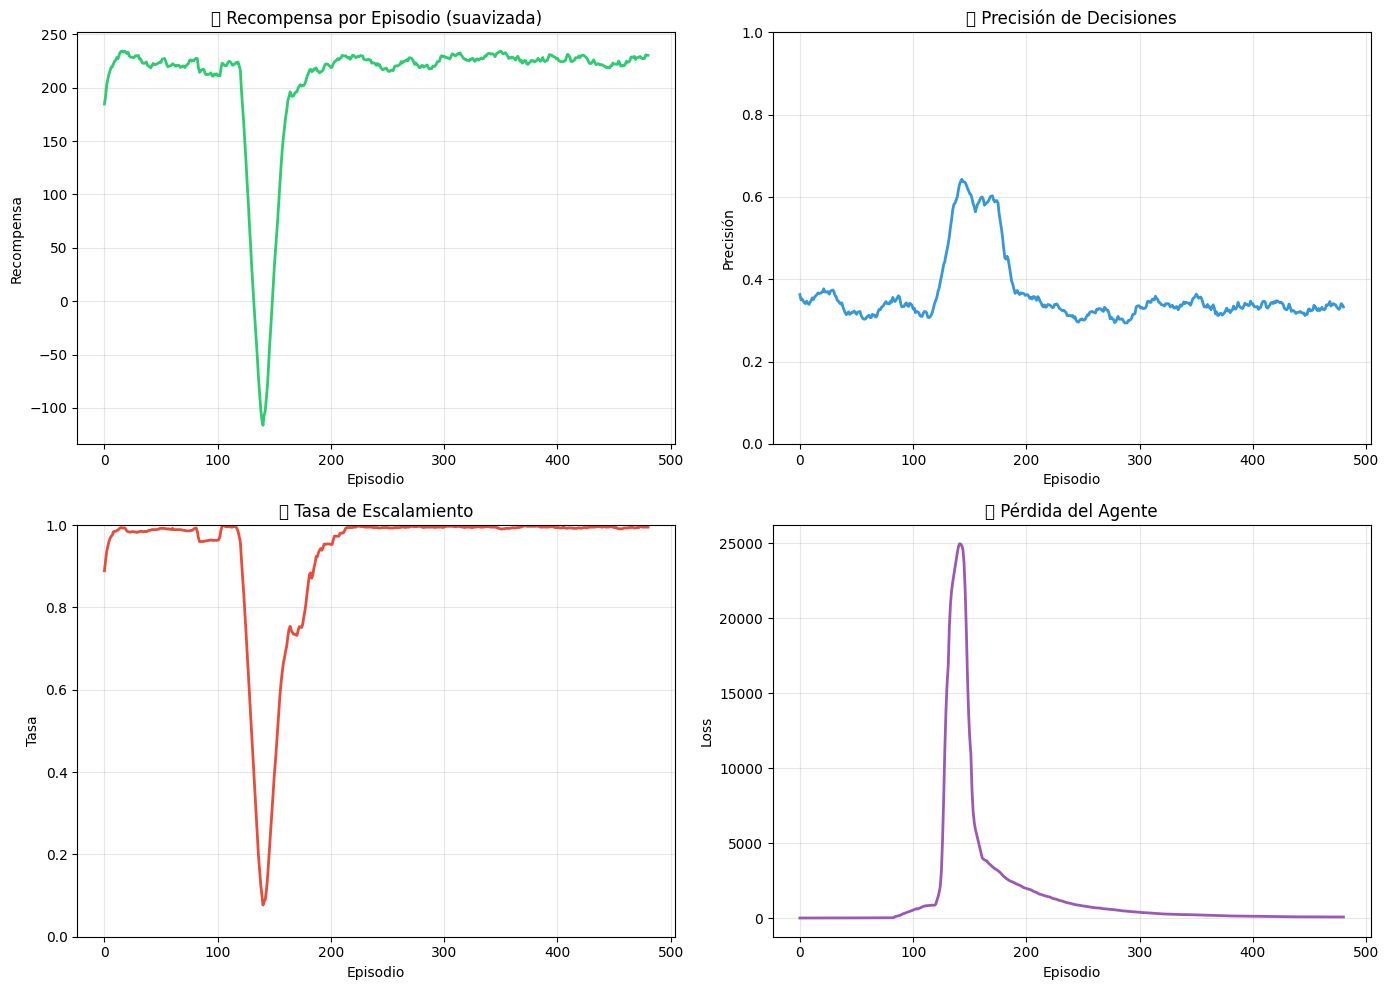


✅ Precisión final: 32.96%
📊 Tasa de escalamiento final: 99.44%


In [9]:
# Graficar métricas de entrenamiento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recompensa
window = 20
smoothed_rewards = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')
axes[0, 0].plot(smoothed_rewards, linewidth=2, color='#2ecc71')
axes[0, 0].set_title('📈 Recompensa por Episodio (suavizada)', fontsize=12)
axes[0, 0].set_xlabel('Episodio')
axes[0, 0].set_ylabel('Recompensa')
axes[0, 0].grid(True, alpha=0.3)

# Precisión
smoothed_correct = np.convolve(correct_decisions, np.ones(window)/window, mode='valid')
axes[0, 1].plot(smoothed_correct, linewidth=2, color='#3498db')
axes[0, 1].set_title('🎯 Precisión de Decisiones', fontsize=12)
axes[0, 1].set_xlabel('Episodio')
axes[0, 1].set_ylabel('Precisión')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(True, alpha=0.3)

# Tasa de escalamiento
smoothed_escalation = np.convolve(escalation_rates, np.ones(window)/window, mode='valid')
axes[1, 0].plot(smoothed_escalation, linewidth=2, color='#e74c3c')
axes[1, 0].set_title('🚨 Tasa de Escalamiento', fontsize=12)
axes[1, 0].set_xlabel('Episodio')
axes[1, 0].set_ylabel('Tasa')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].grid(True, alpha=0.3)

# Loss
if any(episode_losses):
    smoothed_loss = np.convolve([l for l in episode_losses if l > 0],
                                np.ones(window)/window, mode='valid')
    axes[1, 1].plot(smoothed_loss, linewidth=2, color='#9b59b6')
    axes[1, 1].set_title('📉 Pérdida del Agente', fontsize=12)
    axes[1, 1].set_xlabel('Episodio')
    axes[1, 1].set_ylabel('Loss')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rl_training_curves.png', dpi=150)
plt.show()

print(f"\n✅ Precisión final: {np.mean(correct_decisions[-50:]):.2%}")
print(f"📊 Tasa de escalamiento final: {np.mean(escalation_rates[-50:]):.2%}")

## 8. Evaluar el Agente

In [10]:
# Evaluación con casos específicos
print("🧪 Evaluación del Agente con Casos de Prueba:\n")
print("=" * 70)

test_cases = [
    # (Clase, Confianza, Descripción esperada)
    (2, 0.92, "Melanoma alta confianza → DEBE escalar"),
    (2, 0.55, "Melanoma baja confianza → DEBE escalar"),
    (3, 0.95, "Nevus alta confianza → NO escalar"),
    (3, 0.45, "Nevus baja confianza → Debería escalar"),
    (0, 0.75, "Carcinoma basocelular media confianza → Debería escalar"),
    (5, 0.60, "Queratosis actínica media confianza → Puede escalar"),
]

agent.epsilon = 0  # Desactivar exploración para evaluación

for class_idx, target_conf, description in test_cases:
    # Generar predicción con confianza específica
    probs = np.random.dirichlet(np.ones(NUM_CLASSES)) * (1 - target_conf)
    probs[class_idx] += target_conf
    probs = probs / probs.sum()  # Re-normalizar

    state = agent.get_state(probs)
    action = agent.act(state, training=False)

    action_text = "🚨 ESCALAR" if action == 1 else "✅ No escalar"
    class_name = CLASS_NAMES[class_idx]

    print(f"\n📋 {description}")
    print(f"   Diagnóstico: {class_name}")
    print(f"   Confianza: {target_conf:.1%}")
    print(f"   Decisión: {action_text}")

print("\n" + "=" * 70)

🧪 Evaluación del Agente con Casos de Prueba:


📋 Melanoma alta confianza → DEBE escalar
   Diagnóstico: dermatofibroma
   Confianza: 92.0%
   Decisión: 🚨 ESCALAR

📋 Melanoma baja confianza → DEBE escalar
   Diagnóstico: dermatofibroma
   Confianza: 55.0%
   Decisión: 🚨 ESCALAR

📋 Nevus alta confianza → NO escalar
   Diagnóstico: melanoma
   Confianza: 95.0%
   Decisión: 🚨 ESCALAR

📋 Nevus baja confianza → Debería escalar
   Diagnóstico: melanoma
   Confianza: 45.0%
   Decisión: 🚨 ESCALAR

📋 Carcinoma basocelular media confianza → Debería escalar
   Diagnóstico: actinic keratosis
   Confianza: 75.0%
   Decisión: 🚨 ESCALAR

📋 Queratosis actínica media confianza → Puede escalar
   Diagnóstico: pigmented benign keratosis
   Confianza: 60.0%
   Decisión: 🚨 ESCALAR



## 9. Guardar el Agente

In [11]:
# Guardar el agente entrenado
agent.save('escalation_agent')

print("\n📁 Archivos generados:")
print("   - escalation_agent_model.keras")
print("   - escalation_agent_config.json")
print("   - rl_training_curves.png")

✅ Agente guardado en escalation_agent

📁 Archivos generados:
   - escalation_agent_model.keras
   - escalation_agent_config.json
   - rl_training_curves.png


In [12]:
# Descargar archivos (en Colab)
try:
    from google.colab import files

    print("📥 Descargando archivos del agente RL...")
    files.download('escalation_agent_model.keras')
    files.download('escalation_agent_config.json')
    files.download('rl_training_curves.png')
    print("✅ Descarga completada!")
except:
    print("⚠️ No estás en Colab. Los archivos están en el directorio actual.")
    for f in ['escalation_agent_model.keras', 'escalation_agent_config.json']:
        if os.path.exists(f):
            size = os.path.getsize(f) / 1024
            print(f"   ✓ {f} ({size:.1f} KB)")

📥 Descargando archivos del agente RL...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga completada!


---

## ✅ ¡Entrenamiento del Agente RL Completado!

### Próximos pasos:
1. Descarga los archivos del agente a tu PC
2. Colócalos en la carpeta `models/` junto con el modelo CNN
3. Ejecuta `python backend/app.py` para iniciar el servidor
4. Abre http://localhost:5000 en tu navegador

### Archivos necesarios en `models/`:
- `dermaai_model_final.keras` (del notebook 01)
- `class_info.json` (del notebook 01)
- `escalation_agent_model.keras` (de este notebook)
- `escalation_agent_config.json` (de este notebook)